In [ ]:
import pandas as pd
import random
import numpy as np
from equations import flops, memory, latency, energy

In [2]:
results = pd.read_csv("/Users/tatyana/Projects/Efficient-Models_ITMO/results/mesaruments.csv")
results

,S,B,latency,"memory, mb",energy,"memory_calculated, mb"
0,32,1,0.000642,12.16,0.013620,4.07
1,32,2,0.000634,12.23,0.013635,4.17
2,32,4,0.000626,12.36,0.013695,4.37
3,32,8,0.000666,12.63,0.013637,4.78
4,32,16,0.000689,18.48,0.020490,5.59
...,...,...,...,...,...,...
151,496,256,0.219255,4097.39,34.615416,6250.47
152,496,512,0.437379,8182.19,68.584219,12496.97
153,496,77,0.066934,1241.7,10.483593,1882.80
154,496,69,0.060229,1114.43,9.436444,1687.60


In [7]:
S = results['S'].unique()
B = results['B'].unique()

S = np.array(S)
B = np.array(B)

S = S[:, None]
B = B[None, :]

In [12]:
import json

In [14]:
with open("results/theta.json") as f:
    data = json.load(f)

theta_latency = np.array(list(data["latency"].values()))
theta_energy = np.array(list(data["energy"].values()))
theta_latency, theta_energy

(array([7.35894198e-04, 1.95354796e-13, 1.95332474e-13]),
 array([6.43981475e-11, 1.84471509e-11, 2.07468807e-09]))

In [23]:
flops_results = flops(S, B) 
memory_results = np.round(memory(S, B) /(1024 ** 2), 2)
energy_results = np.round(energy(S, B, theta_latency, theta_energy), 6)
latency_results = np.round(latency(S, B, theta_latency), 6)

In [24]:
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch
from pathlib import Path

FIGURES = Path("results/figures")
FIGURES.mkdir(parents=True, exist_ok=True)

GPU_MB = 12 * 1024  # RTX 3060, 12 GiB

measured = results.copy()
measured["oom"] = measured["memory, mb"].astype(str).eq("OOM")
ok = measured.loc[~measured["oom"]].copy()
ok["memory_mb"] = ok["memory, mb"].astype(float)
ok["latency_s"] = ok["latency"].astype(float)
ok["energy_j"] = ok["energy"].astype(float)

s_ok = ok["S"].to_numpy(dtype=float)
b_ok = ok["B"].to_numpy(dtype=float)
ok["memory_pred_mb"] = memory(s_ok, b_ok) / (1024 ** 2)
ok["latency_pred_s"] = latency(s_ok, b_ok, theta_latency)
ok["energy_pred_j"] = energy(s_ok, b_ok, theta_latency, theta_energy)

CURVE_S = [32, 64, 128, 224, 256, 384, 512, 1024]
B_LINE = np.linspace(1, 512, 400)


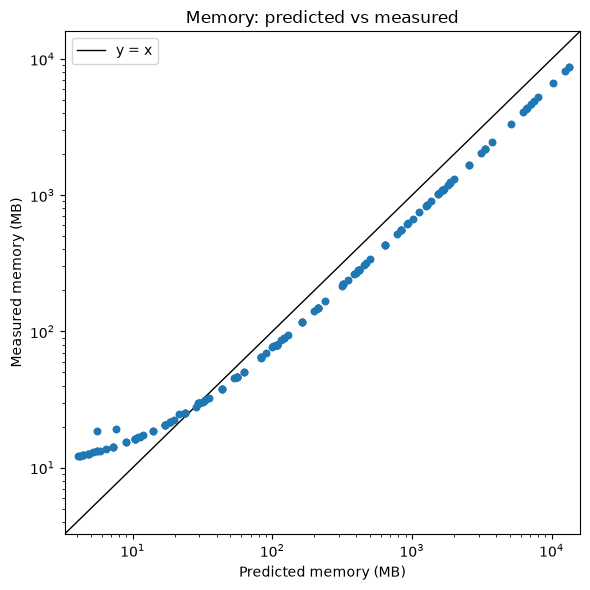

In [25]:
fig, ax = plt.subplots(figsize=(6, 6))
pred = ok["memory_pred_mb"].to_numpy()
meas = ok["memory_mb"].to_numpy()
lo = min(pred.min(), meas.min()) * 0.8
hi = max(pred.max(), meas.max()) * 1.2
ax.scatter(pred, meas, s=22, zorder=3)
ax.plot([lo, hi], [lo, hi], color="black", lw=1, label="y = x")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_xlabel("Predicted memory (MB)")
ax.set_ylabel("Measured memory (MB)")
ax.set_title("Memory: predicted vs measured")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "memory_parity.png", dpi=150)
plt.show()


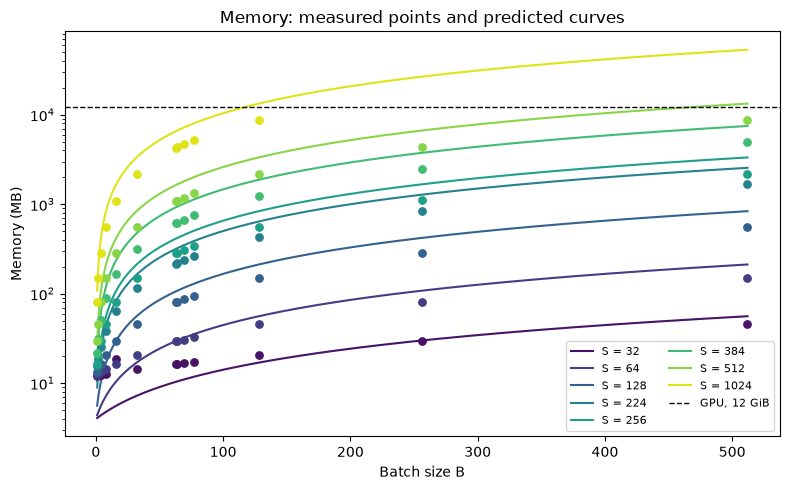

In [26]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.cm.viridis(np.linspace(0.05, 0.95, len(CURVE_S)))
for color, image_size in zip(colors, CURVE_S):
    pred_mb = memory(image_size, B_LINE) / (1024 ** 2)
    ax.plot(B_LINE, pred_mb, color=color, label=f"S = {image_size}")
    pts = ok[ok["S"] == image_size]
    ax.scatter(pts["B"], pts["memory_mb"], color=color, s=28, zorder=3)
ax.axhline(GPU_MB, color="black", ls="--", lw=1, label="GPU, 12 GiB")
ax.set_xlabel("Batch size B")
ax.set_ylabel("Memory (MB)")
ax.set_yscale("log")
ax.set_title("Memory: measured points and predicted curves")
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "memory_vs_batch.png", dpi=150)
plt.show()


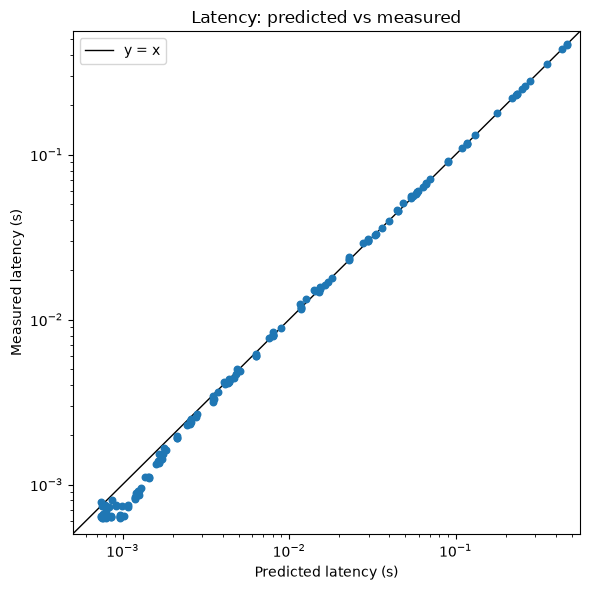

In [27]:
fig, ax = plt.subplots(figsize=(6, 6))
pred = ok["latency_pred_s"].to_numpy()
meas = ok["latency_s"].to_numpy()
lo = min(pred.min(), meas.min()) * 0.8
hi = max(pred.max(), meas.max()) * 1.2
ax.scatter(pred, meas, s=22, zorder=3)
ax.plot([lo, hi], [lo, hi], color="black", lw=1, label="y = x")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_xlabel("Predicted latency (s)")
ax.set_ylabel("Measured latency (s)")
ax.set_title("Latency: predicted vs measured")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "latency_parity.png", dpi=150)
plt.show()


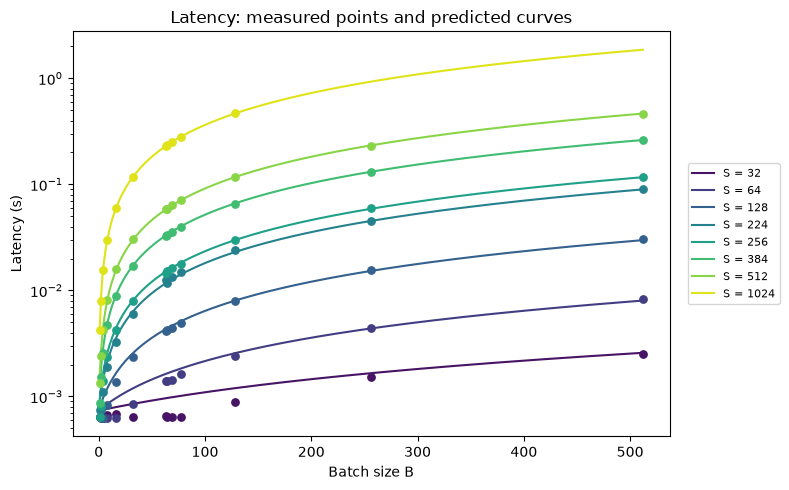

In [28]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.cm.viridis(np.linspace(0.05, 0.95, len(CURVE_S)))
for color, image_size in zip(colors, CURVE_S):
    pred_s = latency(image_size, B_LINE, theta_latency)
    ax.plot(B_LINE, pred_s, color=color, label=f"S = {image_size}")
    pts = ok[ok["S"] == image_size]
    ax.scatter(pts["B"], pts["latency_s"], color=color, s=28, zorder=3)
ax.set_xlabel("Batch size B")
ax.set_ylabel("Latency (s)")
ax.set_yscale("log")
ax.set_title("Latency: measured points and predicted curves")
ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.02, 0.5))
fig.tight_layout()
fig.savefig(FIGURES / "latency_vs_batch.png", dpi=150, bbox_inches="tight")
plt.show()


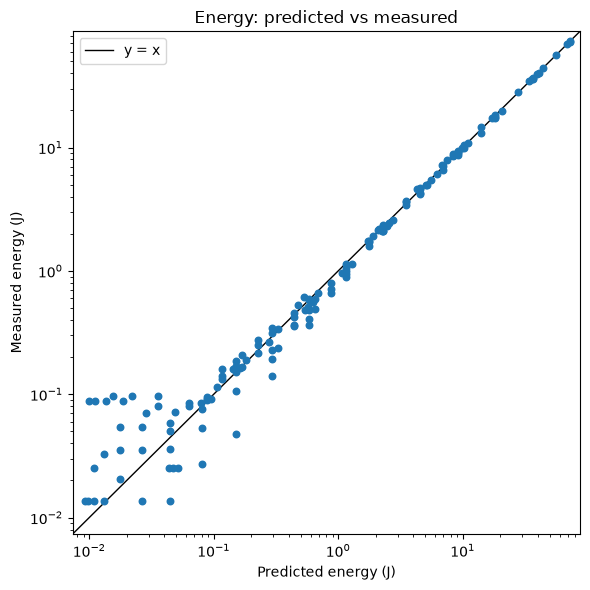

In [29]:
fig, ax = plt.subplots(figsize=(6, 6))
pred = ok["energy_pred_j"].to_numpy()
meas = ok["energy_j"].to_numpy()
lo = min(pred.min(), meas.min()) * 0.8
hi = max(pred.max(), meas.max()) * 1.2
ax.scatter(pred, meas, s=22, zorder=3)
ax.plot([lo, hi], [lo, hi], color="black", lw=1, label="y = x")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_xlabel("Predicted energy (J)")
ax.set_ylabel("Measured energy (J)")
ax.set_title("Energy: predicted vs measured")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "energy_parity.png", dpi=150)
plt.show()


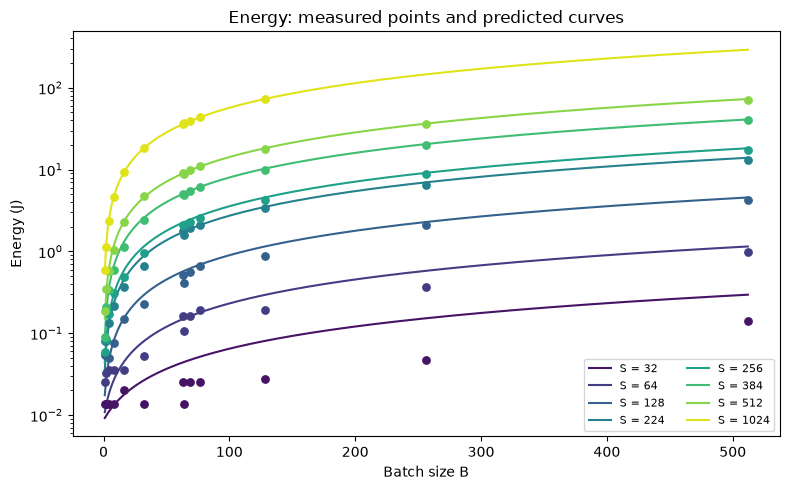

In [30]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.cm.viridis(np.linspace(0.05, 0.95, len(CURVE_S)))
for color, image_size in zip(colors, CURVE_S):
    pred_j = energy(image_size, B_LINE, theta_latency, theta_energy)
    ax.plot(B_LINE, pred_j, color=color, label=f"S = {image_size}")
    pts = ok[ok["S"] == image_size]
    ax.scatter(pts["B"], pts["energy_j"], color=color, s=28, zorder=3)
ax.set_xlabel("Batch size B")
ax.set_ylabel("Energy (J)")
ax.set_yscale("log")
ax.set_title("Energy: measured points and predicted curves")
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "energy_vs_batch.png", dpi=150)
plt.show()


In [ ]:
S_vals = np.arange(32, 1024 + 1, 16)
B_vals = np.linspace(1, 512, 400)
image_grid, batch_grid = np.meshgrid(S_vals, B_vals, indexing="ij")
predicted_mb = memory(image_grid, batch_grid) / (1024 ** 2)
fits = predicted_mb <= GPU_MB

fig, ax = plt.subplots(figsize=(8, 5))
ax.pcolormesh(
    B_vals,
    S_vals,
    fits.astype(float),
    cmap=ListedColormap(["#f4a3a8", "#b7e1c2"]),
    vmin=0,
    vmax=1,
    shading="auto",
)
ax.contour(B_vals, S_vals, predicted_mb, levels=[GPU_MB], colors="black", linewidths=1.2)
ax.scatter(ok["B"], ok["S"], s=18, c="#1f4e79", label="measured, fits", zorder=3)
oom = measured.loc[measured["oom"]]
ax.scatter(oom["B"], oom["S"], s=60, c="#9b2226", marker="x", label="measured OOM", zorder=4)
ax.set_xlim(-10, 540)
ax.set_ylim(0, 1100)
ax.set_xlabel("Batch size B")
ax.set_ylabel("Image size S")
ax.set_title("OOM: measured points and memory(S, B) = 12 GiB")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
fig.tight_layout()
fig.savefig(FIGURES / "oom_map.png", dpi=150)
plt.show()


In [ ]:
S_vals = np.arange(32, 1024 + 1, 16)
B_vals = np.linspace(1, 512, 400)
image_grid, batch_grid = np.meshgrid(S_vals, B_vals, indexing="ij")

theta0, theta1, theta2 = theta_latency
flops_term = flops(image_grid, batch_grid) * theta1
bytes_term = 4 * (91 * batch_grid * image_grid ** 2 + 1040324) * theta2
regime = np.full(image_grid.shape, 2, dtype=int)
regime[bytes_term >= flops_term] = 1
regime[np.maximum(flops_term, bytes_term) <= theta0] = 0

cmap = ListedColormap(["#4C78A8", "#F58518", "#54A24B"])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

fig, ax = plt.subplots(figsize=(8, 5))
ax.pcolormesh(B_vals, S_vals, regime, cmap=cmap, norm=norm, shading="auto")
ax.scatter(ok["B"], ok["S"], s=12, c="black", alpha=0.45, label="measured", zorder=3)
ax.set_xlim(-10, 540)
ax.set_ylim(0, 1100)
ax.set_xlabel("Batch size B")
ax.set_ylabel("Image size S")
ax.set_title("Latency regimes of θ0 + max(FLOPs·θ1, bytes·θ2)")
ax.legend(
    handles=[
        Patch(facecolor="#4C78A8", label="launch-bound"),
        Patch(facecolor="#F58518", label="memory-bound"),
        Patch(facecolor="#54A24B", label="compute-bound"),
    ],
    loc="upper right",
)
fig.tight_layout()
fig.savefig(FIGURES / "latency_regimes.png", dpi=150)
plt.show()
